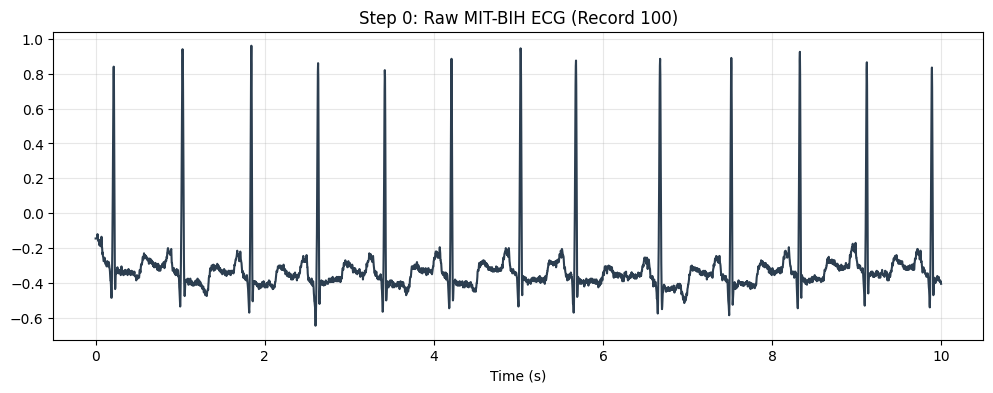

In [13]:
import wfdb
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

record_name = '100'
fs = 360
seconds = 10
total_samples = fs * seconds

print(f"Downloading MIT-BIH Record {record_name}...")
record = wfdb.rdsamp(record_name, pn_dir='mitdb', sampto=total_samples)

raw_signal = record[0][:, 0] 
t = np.arange(total_samples) / fs

plt.plot(t, raw_signal, color='#2c3e50')
plt.title(f"Step 0: Raw MIT-BIH ECG (Record {record_name})")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

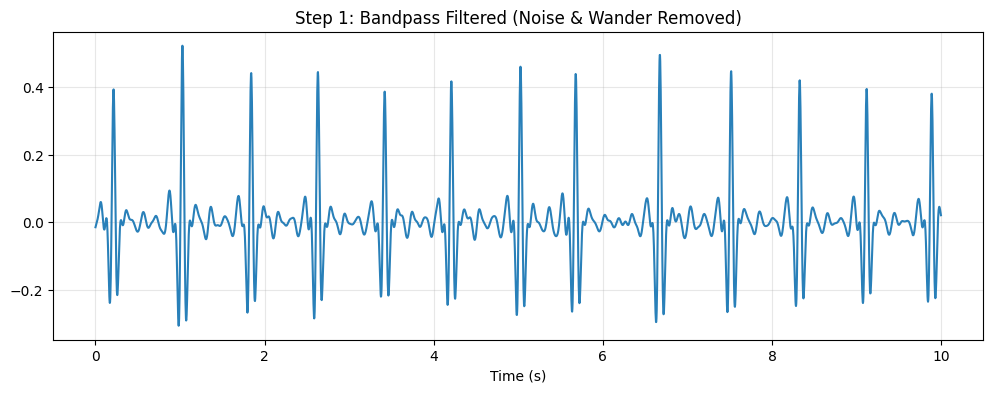

In [14]:
#  Bandpass Filter (5-15 Hz)
nyq = 0.5 * fs
b, a = signal.butter(3, [5.0/nyq, 15.0/nyq], btype='band')
# Using filtfilt to apply the filter forward and backward (zero phase shift)
filtered_signal = signal.filtfilt(b, a, raw_signal)

plt.plot(t, filtered_signal, color='#2980b9')
plt.title("Step 1: Bandpass Filtered (Noise & Wander Removed)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

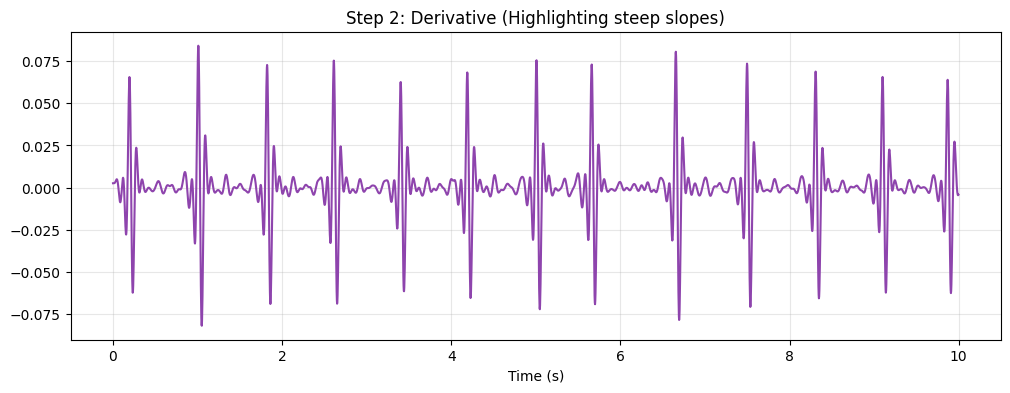

In [15]:
derivative_signal = np.diff(filtered_signal)
derivative_signal = np.insert(derivative_signal, 0, derivative_signal[0])

plt.plot(t, derivative_signal, color='#8e44ad')
plt.title("Step 2: Derivative (Highlighting steep slopes)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

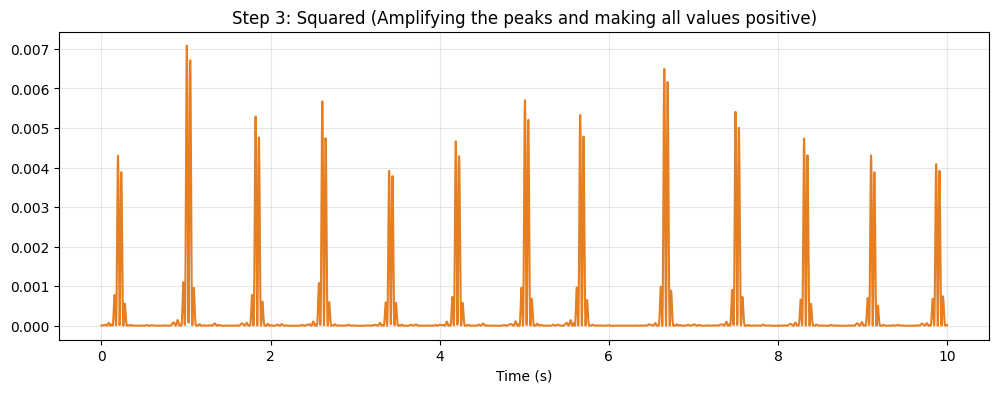

In [16]:
squared_signal = np.square(derivative_signal)

plt.plot(t, squared_signal, color='#e67e22')
plt.title("Step 3: Squared (Amplifying the peaks and making all values positive)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

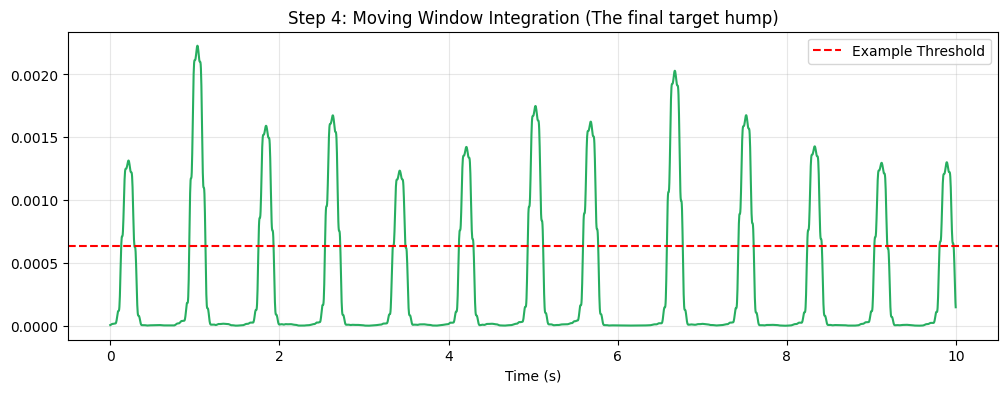

In [22]:
# 150ms is roughly the maximum width of a normal human QRS complex
window_width = int(0.150 * fs) 
window = np.ones(window_width) / window_width

integrated_signal = np.convolve(squared_signal, window, mode='same')

plt.plot(t, integrated_signal, color='#27ae60')
plt.title("Step 4: Moving Window Integration (The final target hump)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)

plt.axhline(y=np.mean(integrated_signal)*2, color='red', linestyle='--', label="Example Threshold")
plt.legend()
plt.show()